# Домашнее задание 9. Проектирование системы целиком

Тема: ML-система для прогноза складских запасов сетевого магазина.

Файлы решения вынесены в репозиторий:

- `dags/inventory_retrain_dag.py` - Airflow DAG
- `src/` - код обучения, оценки и registry
- `infra/` - Terraform
- `.github/workflows/dz9-checks.yml` - CI/CD
- `reports/` - результаты запусков и проверки


In [1]:
stories = [
    ("Книжный Мир", "рекомендации книг", "batch", "по расписанию", "история копится сутками, re-train раз в сутки достаточно"),
    ("Защита Онлайн", "антифрод", "streaming scoring", "по алерту мониторинга", "решение нужно за миллисекунды, re-train при дрейфе фрод-метрик"),
    ("Мой Круг", "лента новостей", "hybrid", "batch + online features", "профиль пользователя считается batch-ом, свежие лайки идут онлайн"),
    ("Быстрый Путь", "динамические цены", "online learning", "по новым событиям", "спрос, машины и пробки меняются постоянно"),
    ("складские запасы", "кейс ДЗ", "batch + reactive retraining", "по batch-файлу / drift alert / TTL", "данные приходят пачками, задержка в минуты или часы допустима"),
]

headers = ("система", "кейс", "архитектура", "trigger", "обоснование")
widths = [18, 20, 27, 28, 70]
print(" | ".join(h.ljust(w) for h, w in zip(headers, widths)))
print("-+-".join("-" * w for w in widths))
for row in stories:
    print(" | ".join(str(value).ljust(w) for value, w in zip(row, widths)))


система            | кейс                 | архитектура                 | trigger                      | обоснование                                                           
-------------------+----------------------+-----------------------------+------------------------------+-----------------------------------------------------------------------
Книжный Мир        | рекомендации книг    | batch                       | по расписанию                | история копится сутками, re-train раз в сутки достаточно              
Защита Онлайн      | антифрод             | streaming scoring           | по алерту мониторинга        | решение нужно за миллисекунды, re-train при дрейфе фрод-метрик        
Мой Круг           | лента новостей       | hybrid                      | batch + online features      | профиль пользователя считается batch-ом, свежие лайки идут онлайн     
Быстрый Путь       | динамические цены    | online learning             | по новым событиям            | спрос, машины и

### Сводка по архитектурам

| # | кейс | архитектура | запуск переобучения | обоснование |
|---|---|---|---|---|
| 1 | книжный магазин / рекомендации | batch | по расписанию | история стабильная, обновления раз в сутки достаточно |
| 2 | антифрод | streaming scoring | по алерту мониторинга | решение нужно за миллисекунды, re-train нужен при дрейфе фрод-метрик |
| 3 | соцсеть / лента | hybrid | batch по расписанию + online features по событиям | долгий профиль пользователя дополняется свежими действиями |
| 4 | такси / динамические цены | online learning | по новым событиям | спрос, машины и пробки меняются постоянно |
| 5 | складские запасы | batch + reactive retraining через S3/File sensor | по новому batch-файлу + по дрейфу качества | остатки, продажи и поставки приходят пачками; задержка в минуты/часы допустима |

Для системы складских запасов выбрана архитектура `batch retraining + reactive trigger` через `S3KeySensor` / `FileSensor` в Airflow. Gate `new_mape <= 15 and new_mape <= baseline_mape` решает, регистрировать новую модель или оставить старую.


## 2. DAG Airflow для ML-системы складских запасов

Архитектура для задания: `batch + reactive retraining`.

Условия автоматического запуска:

- на S3 появился batch с накопленными чеками;
- мониторинг отправил алерт по деградации качества;
- срок действия модели подходит к концу.

Код DAG вынесен в `dags/inventory_retrain_dag.py`. Ниже ячейка печатает текущую версию файла из репозитория.


In [2]:
from pathlib import Path

path = Path("dags/inventory_retrain_dag.py")
text = path.read_text(encoding="utf-8")
lines = text.splitlines()
checks = ["S3KeySensor", "FileSensor", "validate_inventory_data", "compare_with_baseline", "register_model", "skip_deploy"]

print(f"{path}: {len(lines)} lines")
for token in checks:
    print(f"{token}: {'ok' if token in text else 'missing'}")


dags/inventory_retrain_dag.py: 164 lines
S3KeySensor: ok
FileSensor: ok
validate_inventory_data: ok
compare_with_baseline: ok
register_model: ok
skip_deploy: ok


**DAG inventory_retrain_pipeline**

```text
wait_for_inventory_batch
  -> load_inventory_data
  -> validate_inventory_data
  -> train_model
  -> evaluate_model
  -> compare_with_baseline
  -> register_model / skip_deploy
  -> finish
```

| сценарий запуска | реализация |
|---|---|
| batch на S3 | `S3KeySensor` ждет `incoming/{{ ds }}/inventory.csv` |
| локальная проверка | `FileSensor` ждет `data/demo_inventory_batch.csv` |
| деградация качества | мониторинг создает ручной/REST запуск DAG |
| TTL модели | отдельная проверка registry может создать marker-файл для sensor |

Результаты запуска сохранены в `reports/`: `airflow_task_logs.md`, `airflow_compare_log.md`, `airflow_registry_log.md`, `model_metrics.md`.


## 3. CI/CD и IaC

В задании требуется показать CI/CD pipeline и код инфраструктуры.

Файлы решения:

- `.github/workflows/dz9-checks.yml` - проверки Python и Terraform;
- `docker-compose.yml` - локальный стенд Airflow + MinIO;
- `infra/*.tf` - Terraform для storage / registry / Airflow manifest / pipeline contract.


In [3]:
from pathlib import Path

path = Path("docker-compose.yml")
text = path.read_text(encoding="utf-8")
services = ["minio", "minio-init", "airflow"]

print(f"{path}: {len(text.splitlines())} lines")
for service in services:
    print(f"service {service}: {'ok' if f'{service}:' in text else 'missing'}")


docker-compose.yml: 71 lines
service minio: ok
service minio-init: ok
service airflow: ok


In [4]:
from pathlib import Path

path = Path(".github/workflows/dz9-checks.yml")
text = path.read_text(encoding="utf-8")
checks = ["Python compile", "Model smoke check", "Terraform fmt", "Terraform validate", "Terraform plan"]

print(f"{path}: {len(text.splitlines())} lines")
for item in checks:
    print(f"{item}: {'ok' if item in text else 'missing'}")


.github/workflows/dz9-checks.yml: 63 lines
Python compile: ok
Model smoke check: ok
Terraform fmt: ok
Terraform validate: ok
Terraform plan: ok


In [5]:
%%timeit -n 10 -r 5
# Benchmark inference latency: joblib.load + pandas.read_csv + predict.
# Эти измерения связаны с MDD-блоком ниже: latency reference vs new.
import joblib
import pandas as pd

m = joblib.load("models/inventory_model.joblib")
df = pd.read_csv("data/inventory_test.csv").head(64)
df["date"] = pd.to_datetime(df["date"])
df["day_of_week"] = df["date"].dt.dayofweek
m.predict(df[["store_id", "sku_id", "stock_qty", "sales_qty", "delivery_qty", "day_of_week"]])


The slowest run took 29.07 times longer than the fastest. This could mean that an intermediate result is being cached.
13.1 ms ± 22.2 ms per loop (mean ± std. dev. of 5 runs, 10 loops each)


In [6]:
from pathlib import Path

for name in ["infra/providers.tf", "infra/main.tf", "infra/variables.tf", "infra/outputs.tf"]:
    path = Path(name)
    text = path.read_text(encoding="utf-8")
    resources = text.count("resource ")
    variables = text.count("variable ")
    outputs = text.count("output ")
    print(f"{name}: {len(text.splitlines())} lines, resources={resources}, variables={variables}, outputs={outputs}")


infra/providers.tf: 12 lines, resources=0, variables=0, outputs=0
infra/main.tf: 29 lines, resources=4, variables=0, outputs=0
infra/variables.tf: 17 lines, resources=0, variables=3, outputs=0
infra/outputs.tf: 15 lines, resources=0, variables=0, outputs=4


In [7]:
from pathlib import Path

print(Path("reports/terraform_destroy_plan.txt").read_text(encoding="utf-8"))



No changes. No objects need to be destroyed.

Either you have not created any objects yet or the existing objects were
already deleted outside of Terraform.



**Lifecycle инфраструктуры**

| часть | режим | причина |
|---|---|---|
| Airflow scheduler/webserver | long-lived | DAG должен принимать batch, alerts и TTL-trigger |
| MinIO/S3 bucket | long-lived | хранение входных batch-файлов |
| model registry | long-lived | хранение версии модели, run id и метрик |
| обучающий compute | ephemeral | нужен только на время `train_model` / `evaluate_model` |
| временные feature files | ephemeral | пересоздаются при новом batch |

CI/CD не обучает модель на каждый push. GitHub Actions проверяет код, DAG и Terraform; переобучение запускает Airflow.


## 4. SLI/SLO и управление рисками

Для системы складских запасов выделены три уровня контроля:

- данные и качество модели;
- код / API inference;
- инфраструктура Airflow, storage и workers.


*Показатели мониторинга для ML-системы складских запасов*

### SLI и SLO

**Business SLI**

| SLI | формула | SLO normal | critical | действие |
|---|---|---|---|---|
| доля SKU с прогнозом на завтра | `SKU_with_forecast / SKU_total` | `>= 95%` ежедневно | `< 90%` | повторный запуск DAG / ручной расчет top-SKU |
| recall дефицитных SKU | `caught_stockouts / actual_stockouts` | `>= 80%` за неделю | `< 65%` | проверить продажи и свежесть данных |

**Model / Data SLI**

| SLI | SLO | critical | действие |
|---|---|---|---|
| MAPE прогноза остатков | `<= 15%` | `> 25%` | `compare_with_baseline` -> `skip_deploy` |
| critical data validation pass rate | `100%` | любой fail | `ValueError` в `validate_inventory_data` |
| data drift по фичам | `PSI <= 0.2` | `PSI > 0.3` | alert + внеочередной retrain DAG |

**Code / API SLI**

| SLI | SLO | critical | действие |
|---|---|---|---|
| p95 latency `/predict` | `< 300 ms` | `> 1000 ms` | MDD test + ADR + rollback при необходимости |
| error rate `/predict` | `< 0.1%` | `> 1% за 5 мин` | rollback на прошлую версию |
| RPS handling | `>= 500 rps` | throughput ниже на 30% | scale-out workers |

**Infrastructure SLI**

| SLI | SLO | critical | действие |
|---|---|---|---|
| successful DAG runs | `>= 99%` daily runs | 2 падения подряд | разбор Airflow / storage / registry |
| S3 availability | `>= 99.5%` за месяц | нет доступа к batch | incident по storage |
| свежесть production model | `< 24h` | `> 72h` | alert дежурному инженеру |

**Escalation policy**

1. Airflow retry закрывает короткие storage/network сбои.
2. Soft alert уходит дежурному ML-инженеру при одном critical breach.
3. Hard incident открывается при двух critical SLO одновременно или недоступности S3 дольше 5 минут.
4. Повторный latency breach запускает MDD test и фиксируется в ADR.


## 5. Metrics Driven Development

Проверяем изменение latency inference path по двум выборкам:

- `data/reference_latency.csv`;
- `data/new_latency.csv`.

Метод: one-sided Mann-Whitney U + bootstrap CI для разности медиан.


reference median: 121.00 ms  (n=48)
new       median: 179.69 ms  (n=48)
Mann-Whitney U:   statistic=2298.000, p_value=0.00000000, alpha=0.05
95% CI median(new - ref): [51.58, 67.86] ms

decision: add cache before stock history read


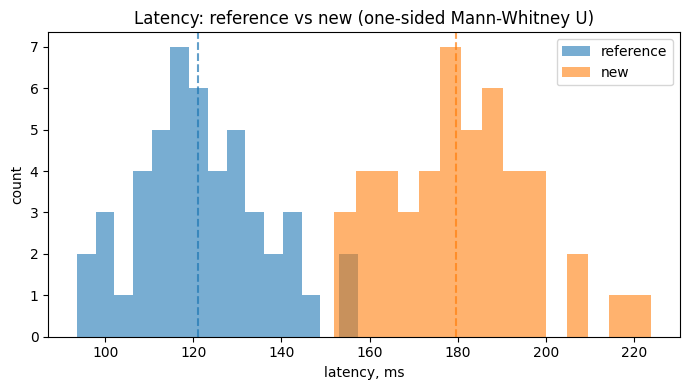

In [8]:
# MDD: статистическая проверка роста latency прогноза складских запасов.
# Reference vs new сохранены в data/reference_latency.csv и data/new_latency.csv.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

ref = pd.read_csv("data/reference_latency.csv")
new = pd.read_csv("data/new_latency.csv")

ref_lat = ref["latency_ms"].to_numpy()
new_lat = new["latency_ms"].to_numpy()

# H0: latency не выросла; H1: new > reference.
stat, p_value = mannwhitneyu(new_lat, ref_lat, alternative="greater")

rng = np.random.default_rng(42)
boot = np.empty(5000)
for i in range(boot.size):
    a = rng.choice(new_lat, size=new_lat.size, replace=True)
    b = rng.choice(ref_lat, size=ref_lat.size, replace=True)
    boot[i] = np.median(a) - np.median(b)
ci_low, ci_high = np.percentile(boot, [2.5, 97.5])

print(f"reference median: {np.median(ref_lat):.2f} ms  (n={ref_lat.size})")
print(f"new       median: {np.median(new_lat):.2f} ms  (n={new_lat.size})")
print(f"Mann-Whitney U:   statistic={stat:.3f}, p_value={p_value:.8f}, alpha=0.05")
print(f"95% CI median(new - ref): [{ci_low:.2f}, {ci_high:.2f}] ms")
print()
decision = "add cache before stock history read" if p_value < 0.05 else "no significant change"
print(f"decision: {decision}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ref_lat, bins=15, alpha=0.6, label="reference")
ax.hist(new_lat, bins=15, alpha=0.6, label="new")
ax.axvline(np.median(ref_lat), color="C0", linestyle="--", alpha=0.7)
ax.axvline(np.median(new_lat), color="C1", linestyle="--", alpha=0.7)
ax.set_xlabel("latency, ms")
ax.set_ylabel("count")
ax.set_title("Latency: reference vs new (one-sided Mann-Whitney U)")
ax.legend()
plt.tight_layout()
plt.savefig("reports/mdd_latency_distribution.png", dpi=120)
plt.show()


*ADR по результатам MDD*

# ADR 0001: решение по росту latency прогноза запасов

Файл ADR: [adr/0001-latency-mdd-decision.md](adr/0001-latency-mdd-decision.md)

## Status

Accepted

## Context

Проверяется SLI `p95_predict_latency`. Использованы две выборки:

- `data/reference_latency.csv` - нормальная история;
- `data/new_latency.csv` - новая версия inference path.

p95 latency новой версии пробила SLO `< 300 ms`, поэтому нужен MDD test до архитектурного решения.

## Decision

- H0: latency не выросла статистически значимо;
- H1: latency выросла статистически значимо;
- test: Mann-Whitney U, `alternative=greater`;
- alpha: `0.05`;
- p-value: `0.00000000`;
- reference median: `121.00 ms`;
- new median: `179.69 ms`.

p-value ниже 0.05. Рост latency считаю статистически значимым.

Решение: добавить cache перед чтением истории остатков и перенести расчет тяжелых lag features в batch preprocessing.

## Consequences

Плюсы:

- ниже latency на inference path;
- меньше повторных чтений истории SKU из storage;
- batch features проще версионировать.

Минусы:

- появляется cache invalidation;
- нужен SLI `feature_freshness`;
- нужно контролировать MAPE после переноса lag features.


## 6. Итоговый вывод

5-8 предложений по итогам проектирования ML-системы.


**Итоговый вывод**

1. Для складских запасов подходит `batch + reactive retraining`: данные приходят пачками, а решение за миллисекунды не требуется.
2. Airflow отвечает за CT loop: ожидание batch, validation, train, evaluate, compare и регистрацию модели.
3. GitHub Actions оставлен для проверок кода, DAG и Terraform; обучение модели в CI/CD не запускается.
4. Перед обучением стоит validation gate, поэтому batch с ошибочной схемой не попадает в `train_model`.
5. Перед регистрацией стоит metric gate: новая модель принимается только если `new_mape <= 15` и она не хуже baseline.
6. Terraform описывает storage, registry path, Airflow manifest и pipeline contract; destroy plan сохранен в `reports/terraform_destroy_plan.txt`.
7. Для рисков заданы SLI/SLO по данным, API и инфраструктуре, чтобы было понятно, когда нужен rollback или разбор инцидента.
8. MDD test показал статистически значимый рост latency, поэтому решение вынесено в ADR: cache перед чтением истории остатков + batch preprocessing для lag features.
